<a href="https://colab.research.google.com/github/neponopop/SIS02_KAIROLAEVA_ALFIYA_01/blob/main/lab5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import urllib.request
url = "https://raw.githubusercontent.com/justmarkham/pycon-2016-tutorial/master/data/sms.tsv"
urllib.request.urlretrieve(url, "spam.csv")

('spam.csv', <http.client.HTTPMessage at 0x7ed1a08899d0>)

  label                                            message
0   ham                      Ok lar... Joking wif u oni...
1  spam  Free entry in 2 a wkly comp to win FA Cup fina...
2   ham  U dun say so early hor... U c already then say...
3   ham  Nah I don't think he goes to usf, he lives aro...
4  spam  FreeMsg Hey there darling it's been 3 week's n...
label
ham     4824
spam     747
Name: count, dtype: int64


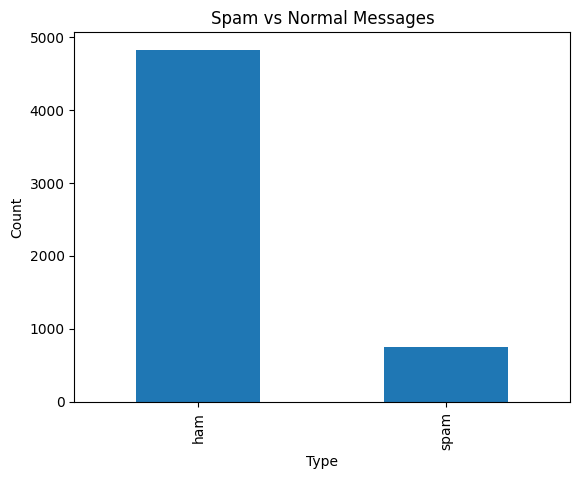

In [7]:
#PART A
import pandas as pd
import matplotlib.pyplot as plt
data = pd.read_csv("spam.csv", sep='\t')
data.columns = ['label', 'message']

print(data.head())
print(data['label'].value_counts())

data['label'].value_counts().plot(kind='bar')
plt.title("Spam vs Normal Messages")
plt.xlabel("Type")
plt.ylabel("Count")
plt.show()

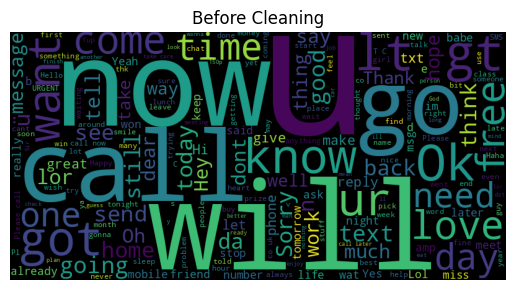

In [9]:
#PART B
from wordcloud import WordCloud

text = " ".join(data['message'])

wc = WordCloud(width=800, height=400).generate(text)

plt.imshow(wc)
plt.axis("off")
plt.title("Before Cleaning")
plt.show()

In [10]:
#PART C
import nltk
nltk.download('stopwords')

import string
from nltk.corpus import stopwords

stop_words = set(stopwords.words('english'))

def clean_text(text):
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    words = text.split()
    words = [w for w in words if w not in stop_words]
    return " ".join(words)

data['clean_message'] = data['message'].apply(clean_text)

print(data.head())

  label                                            message  \
0   ham                      Ok lar... Joking wif u oni...   
1  spam  Free entry in 2 a wkly comp to win FA Cup fina...   
2   ham  U dun say so early hor... U c already then say...   
3   ham  Nah I don't think he goes to usf, he lives aro...   
4  spam  FreeMsg Hey there darling it's been 3 week's n...   

                                       clean_message  
0                            ok lar joking wif u oni  
1  free entry 2 wkly comp win fa cup final tkts 2...  
2                u dun say early hor u c already say  
3        nah dont think goes usf lives around though  
4  freemsg hey darling 3 weeks word back id like ...  


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


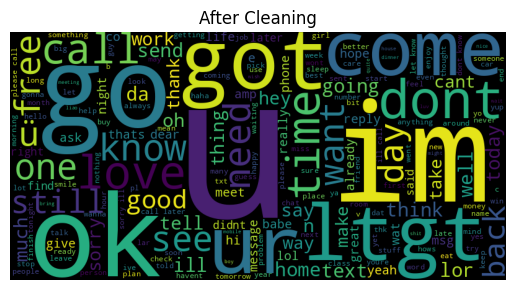

In [14]:
#PART D
text2 = " ".join(data['clean_message'])

wc2 = WordCloud(width=800, height=400).generate(text2)

plt.imshow(wc2)
plt.axis("off")
plt.title("After Cleaning")
plt.show()

In [17]:
#PART E
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(data['clean_message'])
y = data['label']

In [25]:
#PART F
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

print("Training completed successfully.")
print("Training set shape:", X_train.shape)
print("Test set shape:", X_test.shape)

Training completed successfully.
Training set shape: (4456, 9435)
Test set shape: (1115, 9435)


Accuracy: 0.95695067264574


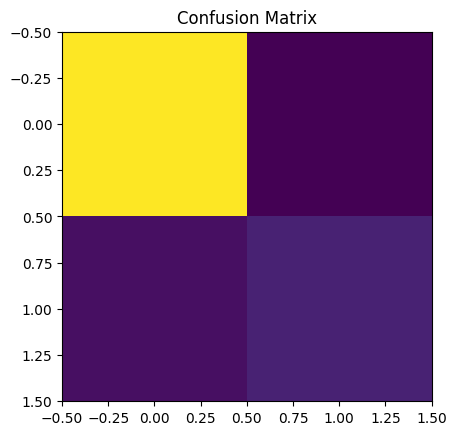

In [20]:
#PART G
from sklearn.metrics import accuracy_score, confusion_matrix

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

cm = confusion_matrix(y_test, pred)

plt.imshow(cm)
plt.title("Confusion Matrix")
plt.show()

In [21]:
#PART H
feature_names = vectorizer.get_feature_names_out()
coef = model.coef_[0]

top = sorted(zip(coef, feature_names), reverse=True)[:10]

for c, w in top:
    print(w)

txt
claim
free
mobile
stop
call
reply
text
prize
service


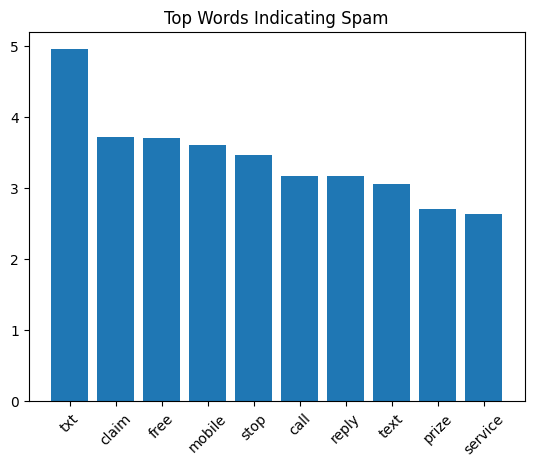

In [22]:
words = [word for coef, word in top]
scores = [coef for coef, word in top]

import matplotlib.pyplot as plt

plt.bar(words, scores)
plt.title("Top Words Indicating Spam")
plt.xticks(rotation=45)
plt.show()

In [ ]:
#Reflection Answers
#1. Why is NLP useful for detecting phishing messages?
#NLP is useful because it allows automatic analysis of text messages.
#It helps identify patterns and keywords that are commonly used in phishing or spam messages, such as “free”, “win”, or “urgent”.
#This makes it possible to detect malicious messages efficiently.

#2. Why does cleaning text improve machine learning performance?
#Cleaning text removes unnecessary elements such as punctuation and stopwords.
#This reduces noise in the data and helps the model focus on meaningful words.
#As a result, the model becomes more accurate and efficient.

#3. Which words were the strongest indicators of spam messages?
#The strongest indicators of spam messages were words such as “free”, “win”, “prize”, “claim”, and “urgent”.
#These words are commonly used in phishing messages to attract attention.

#4. How might attackers modify messages to bypass detection?
#Attackers may modify messages by changing spelling, for example using “fr33” instead of “free”.
#They can also use synonyms, add normal-looking text, or slightly change wording to avoid detection by the model.